# Saudi Used Car Price Prediction 🚗

End-to-end workflow: data cleaning, exploratory data analysis, feature engineering, model training with cross-validation and hyperparameter tuning, and error analysis.

**Author:** Rayan Omar — Computer Science Student | Data Science Track

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

RANDOM_STATE = 42


## 1. Load the data

In [2]:
df_raw = pd.read_csv("saudi_used_cars_csv_.csv", sep=";", encoding="utf-8-sig")
print("Raw shape:", df_raw.shape)
df_raw.head(3)


Raw shape: (8035, 13)


## 2. Exploratory Data Analysis

### 2.1 Raw price distribution
A large share of listings have `Price = 0`. These are cars marked `Negotiable = TRUE` with no listed asking price — not a real price of zero.

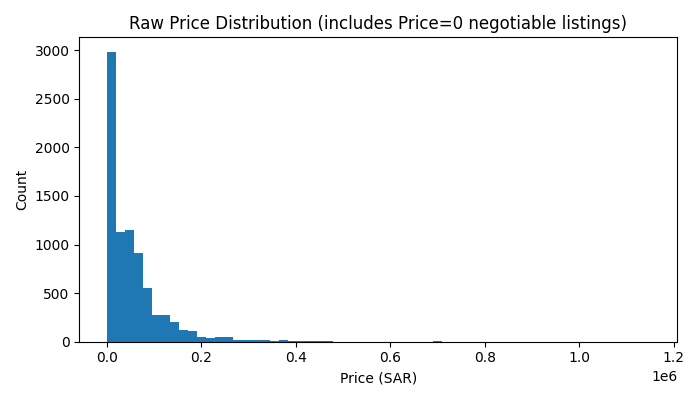

Zero-price rows: 31.4%


In [3]:
plt.figure(figsize=(7,4))
plt.hist(df_raw['Price'], bins=60)
plt.title("Raw Price Distribution (includes Price=0 negotiable listings)")
plt.xlabel("Price (SAR)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

zero_price_pct = (df_raw['Price']==0).mean()*100
print(f"Zero-price rows: {zero_price_pct:.1f}%")


### 2.2 Cleaning decisions
- **Drop `Price == 0` rows** — these carry no usable label; imputing a fake price would corrupt training.
- **Trim top/bottom 1% of `Price`** — removes rare luxury listings and likely data-entry errors.
- **Trim top 0.5% of `Mileage`** — same reasoning.
- **Log-transform the target** — raw price is heavily right-skewed.

In [4]:
df = df_raw[df_raw['Price'] > 0].copy()
low, high = df['Price'].quantile([0.01, 0.99])
df = df[(df['Price'] >= low) & (df['Price'] <= high)]
df = df[df['Mileage'] < df['Mileage'].quantile(0.995)]
print("Clean shape:", df.shape)


Clean shape: (5370, 13)


### 2.3 Price distribution after cleaning (raw vs. log-transformed)

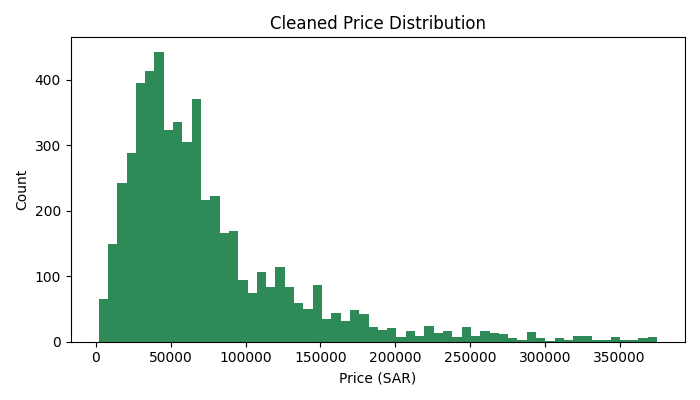

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df['Price'], bins=60, color='seagreen')
axes[0].set_title("Cleaned Price Distribution")
axes[0].set_xlabel("Price (SAR)")
axes[1].hist(np.log1p(df['Price']), bins=60, color='darkorange')
axes[1].set_title("Log(Price+1) Distribution — closer to normal")
axes[1].set_xlabel("log(Price+1)")
plt.tight_layout(); plt.show()


### 2.4 Price vs. Year, Make, and Mileage

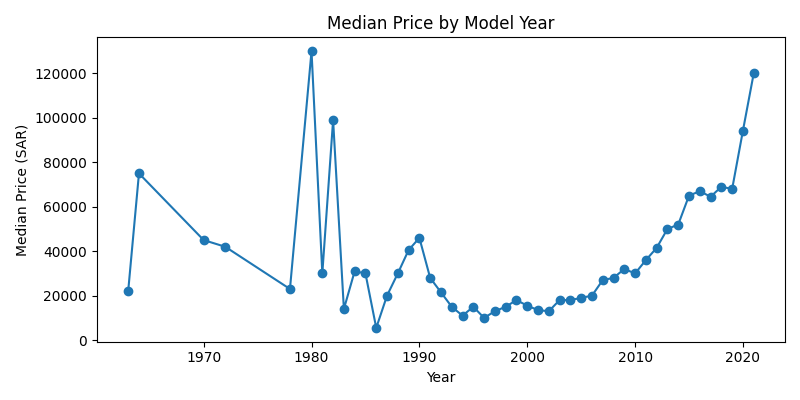

In [6]:
year_price = df.groupby('Year')['Price'].median().sort_index()
plt.figure(figsize=(8,4))
plt.plot(year_price.index, year_price.values, marker='o')
plt.title("Median Price by Model Year")
plt.xlabel("Year"); plt.ylabel("Median Price (SAR)")
plt.tight_layout(); plt.show()


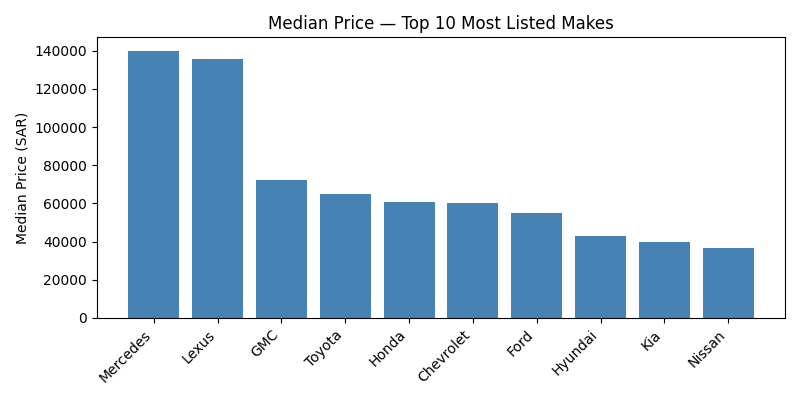

In [7]:
top_makes = df['Make'].value_counts().head(10).index
make_price = df[df['Make'].isin(top_makes)].groupby('Make')['Price'].median().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(make_price.index, make_price.values, color='steelblue')
plt.title("Median Price — Top 10 Most Listed Makes")
plt.ylabel("Median Price (SAR)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


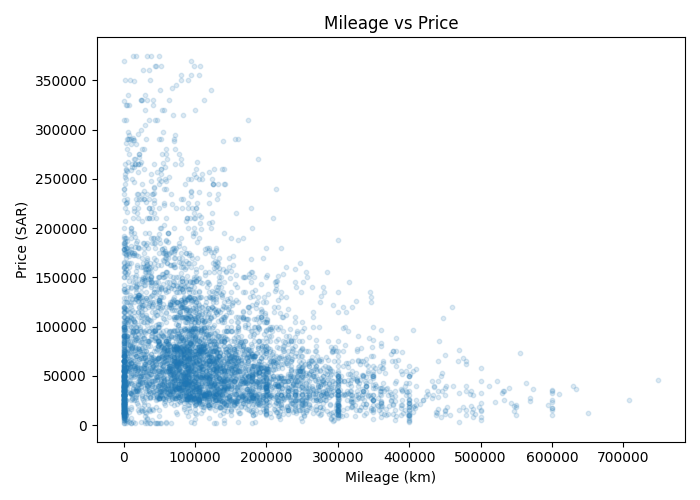

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(df['Mileage'], df['Price'], alpha=0.15, s=10)
plt.title("Mileage vs Price")
plt.xlabel("Mileage (km)"); plt.ylabel("Price (SAR)")
plt.tight_layout(); plt.show()


### 2.5 Correlation between numeric features

             Year  Engine_Size  Mileage  Price
Year         1.00        -0.24    -0.40   0.35
Engine_Size -0.24         1.00     0.17   0.31
Mileage     -0.40         0.17     1.00  -0.29
Price        0.35         0.31    -0.29   1.00


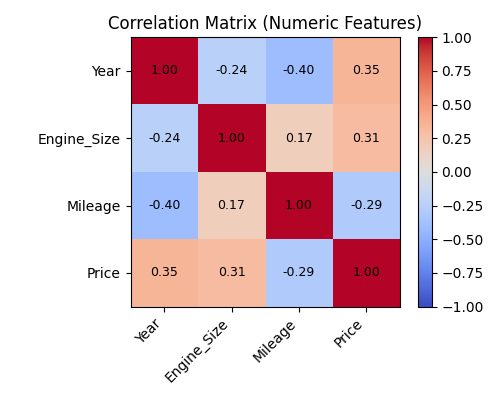

In [9]:
num_df = df[['Year','Engine_Size','Mileage','Price']].corr()
print(num_df.round(2))

plt.figure(figsize=(5,4))
im = plt.imshow(num_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(num_df.columns)), num_df.columns, rotation=45, ha='right')
plt.yticks(range(len(num_df.columns)), num_df.columns)
for i in range(len(num_df.columns)):
    for j in range(len(num_df.columns)):
        plt.text(j, i, f"{num_df.iloc[i,j]:.2f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, fraction=0.046)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout(); plt.show()


## 3. Feature Engineering
Add `Car_Age` (derived from `Year`), one-hot encode categorical columns, and log-transform the target.

In [10]:
df['Car_Age'] = 2026 - df['Year']

X = df.drop(columns=['Price', 'Negotiable'])
y = np.log1p(df['Price'])
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

preprocessor = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train size: {len(X_train)}  Test size: {len(X_test)}")


Categorical columns: ['Make', 'Type', 'Origin', 'Color', 'Options', 'Fuel_Type', 'Gear_Type', 'Region']
Train size: 4296  Test size: 1074


## 4. Baseline Models with Cross-Validation
3-fold cross-validation on the training set gives a more reliable performance estimate than a single train/test split.

In [11]:
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

lin_pipe = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
lin_cv = cross_val_score(lin_pipe, X_train, y_train, cv=kf, scoring='r2')
print(f"LinearRegression 3-fold CV R2: {lin_cv.mean():.3f} +/- {lin_cv.std():.3f}")

rf_base = Pipeline([('pre', preprocessor),
                     ('model', RandomForestRegressor(n_estimators=100, max_depth=16,
                                                      random_state=RANDOM_STATE, n_jobs=1))])
rf_cv = cross_val_score(rf_base, X_train, y_train, cv=kf, scoring='r2')
print(f"RandomForest (default params) 3-fold CV R2: {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")


LinearRegression 3-fold CV R2: 0.530 +/- 0.040
RandomForest (default params) 3-fold CV R2: 0.709 +/- 0.038


## 5. Hyperparameter Tuning
`RandomizedSearchCV` searches over tree count, depth, split/leaf sizes, and feature sampling to find a better Random Forest configuration.

In [12]:
param_dist = {
    'model__n_estimators': [80, 120, 150],
    'model__max_depth': [12, 16, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 0.5],
}

search_pipe = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))])
search = RandomizedSearchCV(
    search_pipe, param_distributions=param_dist, n_iter=4,
    cv=kf, scoring='r2', random_state=RANDOM_STATE, n_jobs=1, verbose=1
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print(f"Best CV R2: {search.best_score_:.3f}")

best_model = search.best_estimator_


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'model__n_estimators': 150, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 20}
Best CV R2: 0.720


## 6. Final Evaluation on the Held-Out Test Set

In [13]:
pred_log = best_model.predict(X_test)
pred = np.expm1(pred_log)
true = np.expm1(y_test)

r2 = r2_score(true, pred)
rmse = np.sqrt(mean_squared_error(true, pred))
mae = mean_absolute_error(true, pred)
print(f"FINAL TEST SET -> R2={r2:.3f}  RMSE={rmse:,.0f}  MAE={mae:,.0f}")


FINAL TEST SET -> R2=0.799  RMSE=26,567  MAE=13,200


### 6.1 Feature importance

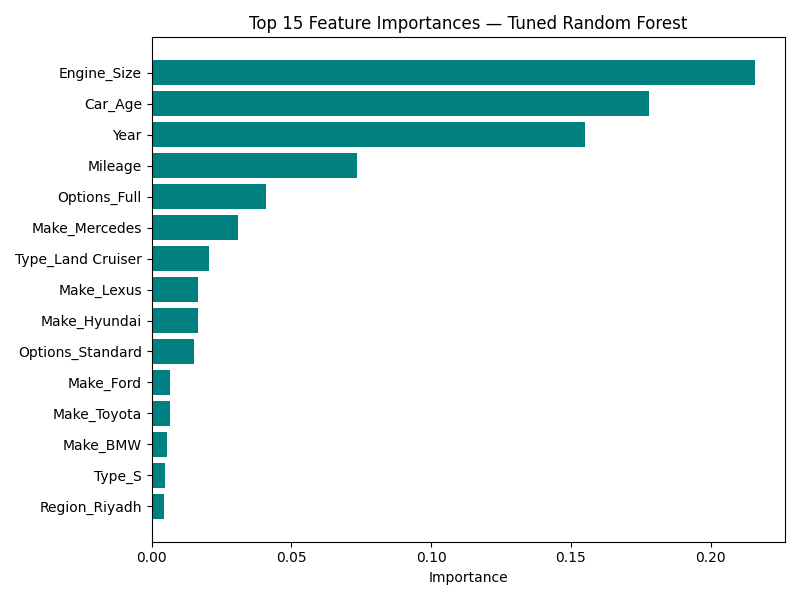

In [14]:
ohe = best_model.named_steps['pre'].named_transformers_['cat']
feature_names = list(ohe.get_feature_names_out(cat_cols)) + [c for c in X.columns if c not in cat_cols]
importances = best_model.named_steps['model'].feature_importances_
top_idx = np.argsort(importances)[-15:]

plt.figure(figsize=(8,6))
plt.barh(np.array(feature_names)[top_idx], importances[top_idx], color='teal')
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — Tuned Random Forest")
plt.tight_layout(); plt.show()


## 7. Error Analysis
Where does the model struggle most? This matters more than the aggregate R² for judging whether the model is usable.

In [15]:
results_df = X_test.copy()
results_df['True_Price'] = true.values
results_df['Predicted_Price'] = pred
results_df['Abs_Error'] = np.abs(results_df['True_Price'] - results_df['Predicted_Price'])
results_df['Pct_Error'] = results_df['Abs_Error'] / results_df['True_Price'] * 100

print("Mean absolute % error:", round(results_df['Pct_Error'].mean(), 1), "%")

worst = results_df.sort_values('Abs_Error', ascending=False).head(10)
worst[['Make','Type','Year','Mileage','True_Price','Predicted_Price','Abs_Error']]


Mean absolute % error: 42.0 %


           Make         Type  Year  Mileage  True_Price  Predicted_Price      Abs_Error
3433   Mercedes            G  2013    32800    375000.0     105183.96       269816.04
3164    Porsche     Panamera  2018    26000    330000.0     108195.34       221804.66
4514   Maserati      Levante  2020      500    370000.0     156350.99       213649.00
7681      Other        Other  1980     2500    220000.0      20416.58       199583.42
809  Land Rover  Range Rover  2019    38000    375000.0     199922.86       175077.14


In [16]:
err_by_make = results_df.groupby('Make')['Abs_Error'].mean().sort_values(ascending=False).head(10)
err_by_make.round(0)


Maserati      213649.0
Other         109401.0
Porsche        56642.0
Jaguar         51870.0
Lincoln        41485.0
Land Rover     34657.0
MINI           34561.0
Mercedes       33656.0
Lexus          23638.0
BMW            23623.0
Name: Abs_Error, dtype: float64


**Takeaway:** the largest errors cluster in rare, high-end brands (Maserati, Porsche, Land Rover, Mercedes) and in an `Other` catch-all category. These makes have few listings in the data, so the model has little signal to learn their pricing pattern from. A production version would benefit from more luxury-segment listings, or a separate model for that price tier.

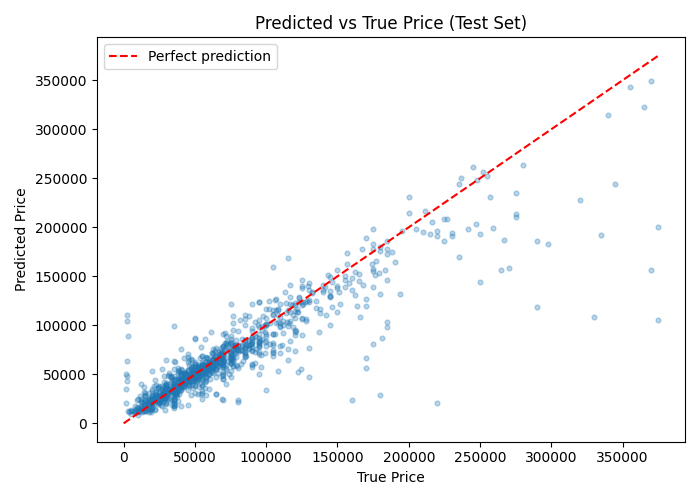

In [17]:
plt.figure(figsize=(7,5))
plt.scatter(results_df['True_Price'], results_df['Predicted_Price'], alpha=0.3, s=12)
mx = results_df['True_Price'].max()
plt.plot([0, mx], [0, mx], 'r--', label='Perfect prediction')
plt.xlabel("True Price"); plt.ylabel("Predicted Price")
plt.title("Predicted vs True Price (Test Set)")
plt.legend()
plt.tight_layout(); plt.show()


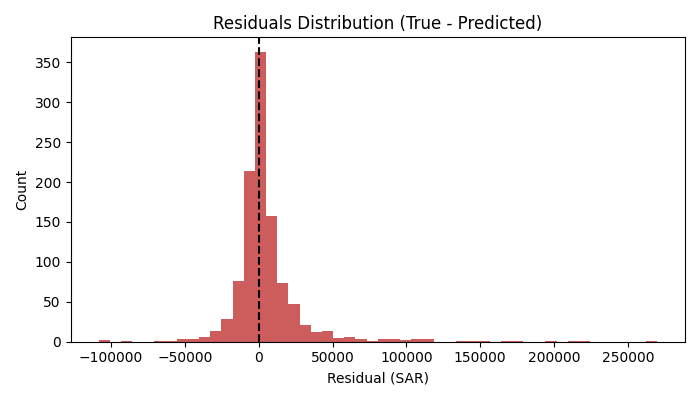

In [18]:
residuals = results_df['True_Price'] - results_df['Predicted_Price']
plt.figure(figsize=(7,4))
plt.hist(residuals, bins=50, color='indianred')
plt.axvline(0, color='black', linestyle='--')
plt.title("Residuals Distribution (True - Predicted)")
plt.xlabel("Residual (SAR)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()


## 8. Save the Model
Persist the tuned pipeline (preprocessing + model) so it can be reused for inference without retraining.

In [19]:
joblib.dump(best_model, "rf_model.joblib")
print("Model saved to rf_model.joblib")


Model saved to rf_model.joblib


## 9. Summary

| Model | CV R² | Test R² | Test RMSE | Test MAE |
|---|---|---|---|---|
| Linear Regression | 0.530 | — | — | — |
| Random Forest (default) | 0.709 | — | — | — |
| **Random Forest (tuned)** | **0.720** | **0.799** | **26,567** | **13,200** |

**Limitations:**
- Mean absolute percentage error is ~42%, driven mostly by rare, high-end makes.
- `Other`-labeled makes/types are a very heterogeneous bucket and are hard to price accurately.
- Predictions should be treated as an estimated range, not an exact valuation.